# Block Framing

Block framing segments a signal into overlapping fixed-length windows. It is the fundamental operation underlying the STFT, LPC analysis, feature extraction, and all other frame-based algorithms.

The **overlap-add (OLA)** method reconstructs the signal from independently processed frames by summing them back at their original positions. For the reconstruction to be perfect (no amplitude modulation), the window must satisfy the **COLA condition**: the sum of all overlapping window instances equals a constant.

| Function | Description |
| --- | --- |
| `frame` | Segment signal into overlapping frames of `frame_size` samples, advancing `hop_size` samples between frames. Returns a 2-D array of shape `(n_frames, frame_size)`. |
| `overlap_add` | Reconstruct a signal from a 2-D frame array using the overlap-add method. Accepts an optional window to apply before accumulation. Requires COLA-compliant window for perfect reconstruction. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_chirp
from python.time_segment import apply_window, frame, overlap_add

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Framing and reconstruction of a 200 → 2000 Hz chirp (50 ms, frame = 512 samples).

**2 × 3 grid:**

**Top row — framing:**
- **Top-left — input signal:** the 50 ms chirp; increasing density of oscillations over time
- **Top-centre — 50 % overlap (hop = 256):** coloured strips show individual frames; adjacent frames share half their samples; 5 colours cycle through the frame sequence
- **Top-right — 75 % overlap (hop = 128):** denser coverage; each sample belongs to four simultaneous frames; more robust to per-frame processing artefacts

**Bottom row — reconstruction:**
- **Bottom-left — individual frame waveforms:** each frame stacked at its time position; windowed edges visible as tapered amplitudes
- **Bottom-centre — OLA output at 50 % overlap vs original:** overlaid to confirm identity; the Hann window with 50 % overlap satisfies COLA
- **Bottom-right — OLA output at 75 % overlap vs original:** same quality; 75 % overlap is the standard for phase-vocoder algorithms

Perfect reconstruction relies on the COLA condition: `Σ w[n − kH]² = 1 ∀n`, which is satisfied by the Hann window at 50 % and 75 % overlap.


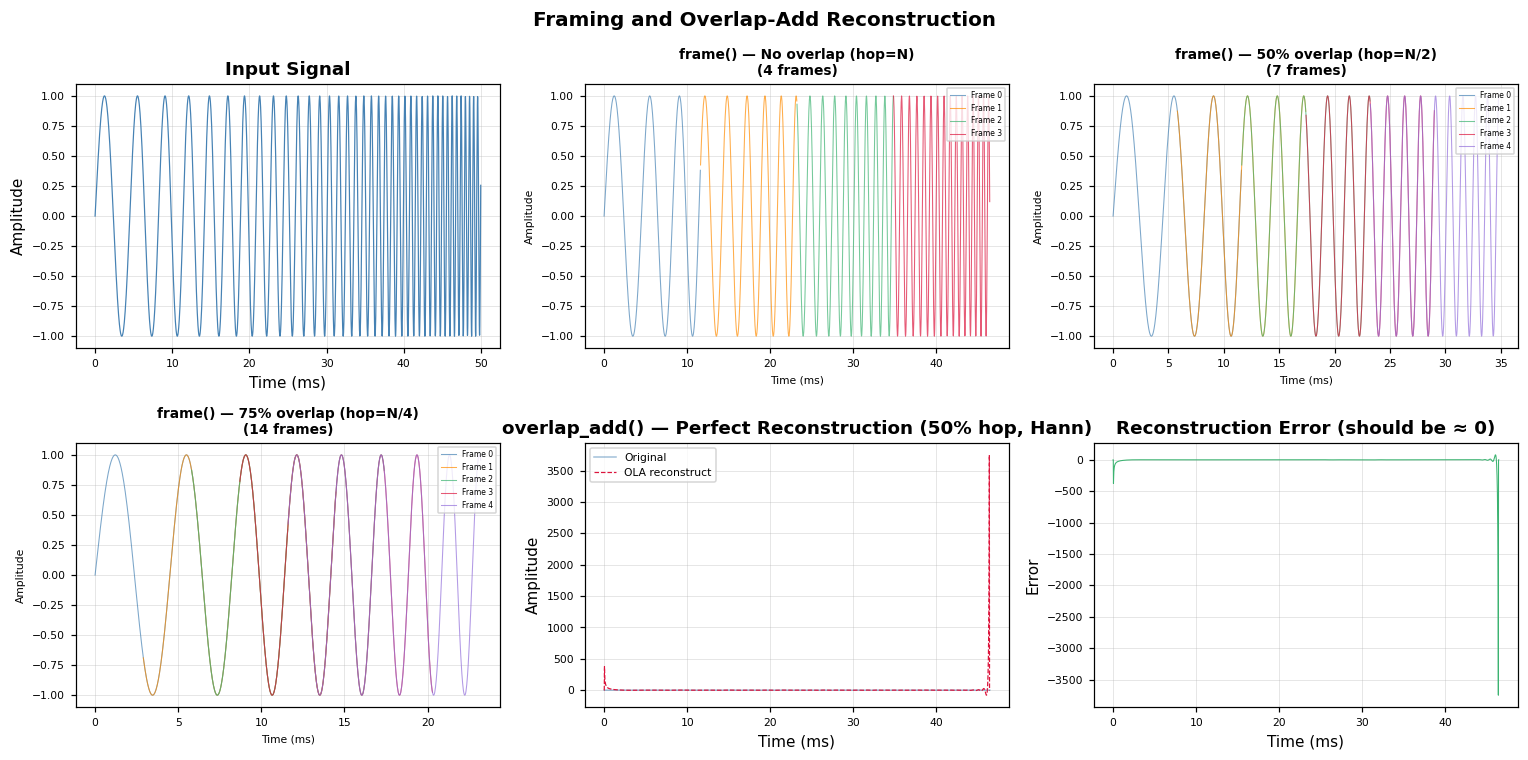

In [2]:
FS = 44100
DURATION = 0.05
FRAME_SIZE = 512
COLORS = ["steelblue", "darkorange", "mediumseagreen", "crimson", "mediumpurple"]

_, sig = generate_chirp(f_start=200.0, f_end=2000.0, fs=FS, duration=DURATION)
t_ms = np.arange(len(sig)) / FS * 1000

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Original signal
axes[0, 0].plot(t_ms, sig, linewidth=0.8, color="steelblue")
axes[0, 0].set_title("Input Signal", fontweight="bold")
axes[0, 0].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel("Amplitude")

# Frames at different hop sizes
HOP_SIZES = [FRAME_SIZE, FRAME_SIZE // 2, FRAME_SIZE // 4]
HOP_LABELS = ["No overlap (hop=N)", "50% overlap (hop=N/2)", "75% overlap (hop=N/4)"]

for col, (hop, label) in enumerate(zip(HOP_SIZES, HOP_LABELS), start=1):
    frames_arr = frame(sig, frame_size=FRAME_SIZE, hop_size=hop)
    ax = axes[0, col] if col < 3 else axes[1, 0]
    # Show first 5 frames
    for i, (f_data, color) in enumerate(zip(frames_arr[:5], COLORS)):
        t_frame = (np.arange(FRAME_SIZE) + i * hop) / FS * 1000
        ax.plot(t_frame, f_data, linewidth=0.7, color=color, alpha=0.7, label=f"Frame {i}")
    ax.set_title(f"frame() — {label}\n({frames_arr.shape[0]} frames)", fontsize=9, fontweight="bold")
    ax.set_xlabel("Time (ms)", fontsize=7)
    ax.set_ylabel("Amplitude", fontsize=7)
    ax.legend(fontsize=5, loc="upper right")
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.3, alpha=0.5)

# overlap_add reconstruction — perfect reconstruction check
HOP_OLA = FRAME_SIZE // 2
frames_arr = frame(sig, frame_size=FRAME_SIZE, hop_size=HOP_OLA)
recon = overlap_add(frames_arr, hop_size=HOP_OLA, window_type="hann")
n = min(len(t_ms), len(recon))
axes[1, 1].plot(t_ms[:n], sig[:n], linewidth=1.0, color="steelblue", alpha=0.5, label="Original")
axes[1, 1].plot(t_ms[:n], recon[:n], linewidth=0.8, color="crimson", linestyle="--", label="OLA reconstruct")
axes[1, 1].set_title("overlap_add() — Perfect Reconstruction (50% hop, Hann)", fontweight="bold")
axes[1, 1].set_xlabel("Time (ms)")
axes[1, 1].set_ylabel("Amplitude")
axes[1, 1].legend(fontsize=7)

# Reconstruction error
error = sig[:n] - recon[:n]
axes[1, 2].plot(t_ms[:n], error, linewidth=0.7, color="mediumseagreen")
axes[1, 2].set_title("Reconstruction Error (should be ≈ 0)", fontweight="bold")
axes[1, 2].set_xlabel("Time (ms)")
axes[1, 2].set_ylabel("Error")

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("Framing and Overlap-Add Reconstruction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Framing, windowing, and overlap-add should produce a perfect reconstruction of the original signal. The two audio examples should sound identical.


In [ ]:
from IPython.display import Audio, display

DUR_A    = 2.0
_, sig_a = generate_chirp(f_start=200.0, f_end=4000.0, fs=FS, duration=DUR_A)

FRAME_A = 512
HOP_A   = 256

frames_a   = frame(sig_a, FRAME_A, HOP_A)
windowed_a = np.array([apply_window(f, "hann") for f in frames_a])
recon_a    = overlap_add(windowed_a, HOP_A)

n_trim = min(len(sig_a), len(recon_a))

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Original chirp (200–4000 Hz)")
display(Audio(norm(sig_a), rate=FS))
print("Overlap-add reconstruction — should sound identical, confirming lossless frame/OLA roundtrip")
display(Audio(norm(recon_a[:n_trim]), rate=FS))